# Local expmnation of noun phrases of VLM
### Step 1: Generate the concept matix for noun phrases for (crop, concept pair)
### Step 2: Run an inference with an image or without an image. get all the embedding of the noun phrases
### Step 3: Select one embedding corresponds to the noun phrase of step 2 
### Step 4: Project the embedding to the concept matrix and get the corresponding images
### Step 5: Select random images from the concept matrix and ask VLM to describe the images and get the noun phrases from them.


## Generate Concept matrix

In [16]:
import torch

In [17]:

# Get the feature for one image 
# Prompt: 
!export HF_HOME=/mnt/abka03/huggingface/hub
concept_example = "Animal" #{concept_example.replace(' ', '_')}
image = f"/mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_6803.JPEG"
#image = "/mnt/abka03/Projects/xl-vlms/playground/dataset/recipe-desktop-merkts-cheesy-hot-dawg.jpg"
!cd ../ && python src/save_features.py \
    --model_name "google/gemma-3n-E4B-it"\
    --dataset_name "image" \
    --data_dir $image \
    --hook_name "save_hidden_states_sentence" \
    --modules_to_hook "model.language_model.norm" \
    --save_dir "/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet3/train" \
    --save_filename "qw3een2" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --token_of_interest $"{concept_example}"\
    --prompt_template "oneword" \
    --concept $"{concept_example}" \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 09:28:08,119 - INFO - Loading model: google/gemma-3n-E4B-it
2025-08-22 09:28:08,119 - INFO - Arguments:
2025-08-22 09:28:08,119 - INFO - seed: 0
2025-08-22 09:28:08,119 - INFO - model_name_or_path: google/gemma-3n-E4B-it
2025-08-22 09:28:08,119 - INFO - processor_name: None
2025-08-22 09:28:08,119 - INFO - local_files_only: False
2025-08-22 09:28:08,119 - INFO - cache_dir: /mnt/abka03/xl-vlms/cache
2025-08-22 09:28:08,120 - INFO - prompt_template: oneword
2025-08-22 09:28:08,120 - INFO - prompt: Describe the image in detail.
2025-08-22 09:28:08,120 - INFO - data_dir: /mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_6803.JPEG
2025-08-22 09:28:08,120 - INFO - annotation_file: annotations.json
2025-08-22 09:28:08,120 - INFO - questions_file: annotations.json
2025-08-22 09:28:08,120 - INFO - answer_type_to_answer: None
2025-08-22 09:28:08,120 - INFO - split: trai

In [20]:
# Project the image to the concept and explain 

import sys

script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)

from analysis.feature_decomposition import get_feature_matrix
module_name ="model.language_model.norm"
token_idx = None
output = torch.load("/mnt/abka03/concept_extraction_result/MCoX/SNMF/layer_norm_imagenet3/train/features/save_hidden_states_sentence_qw3een2.pth")


absolute_features = output["hidden_states"]

feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )



phrase_and_text_prediction = output["model_predictions"]
phrases = [out[0].split("@")[0] for out in phrase_and_text_prediction]
print("Model predcition is: ", output["model_predictions"][0][0].split("@")[0])
print("Phrases are: ", phrases)

test_image_file_name = output["image"]

Model predcition is:  Animal
Phrases are:  ['Animal']


In [21]:
import os

def delete_all_files(folder_path):
    """
    Delete all files in the specified folder.
    """
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            os.remove(file_path)

# Example usage:
delete_all_files("/mnt/abka03/xlvlm_data/oneclass/oneimage")
delete_all_files("/mnt/abka03/xlvlm_data/oneclass/oneimage_crops")
delete_all_files("/mnt/abka03/concept_extraction_result/oneclass/gemma3n/MCoX/SNMF/rabbit/train/features")
delete_all_files("/mnt/abka03/concept_extraction_result/oneclass/gemma3n/MCoX/SNMF/rabbit/train/concept")

In [22]:
# delete all fiels inside a dir

#create version of image

import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
import os
import random

def augment_image(input_path, output_dir, num_variants=5):
    """
    Generate augmented versions of an image (color, noise, brightness, grayscale, etc.)
    and save them with the same size and format.

    Args:
        input_path (str): Path to input image
        output_dir (str): Directory where augmented images will be saved
        num_variants (int): Number of augmented variations to create
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Load original image (Pillow for flexibility)
    img = Image.open(input_path)
    img_format = img.format  # keep same format
    img_name = os.path.splitext(os.path.basename(input_path))[0]

    for i in range(num_variants):
        aug_img = img.copy()

        # Randomly apply augmentations
        choice = random.choice([
            "brightness", "contrast", "grayscale",   "noise", 
        ])
        #choice = "none"

        if choice == "none":
            save_path = os.path.join(output_dir, f"{img_name}.{img_format.lower()}")
            aug_img.save(save_path, format=img_format)

        elif choice == "color_shift":
            enhancer = ImageEnhance.Color(aug_img)
            aug_img = enhancer.enhance(random.uniform(0.2, 1.5))

        elif choice == "brightness":
            enhancer = ImageEnhance.Brightness(aug_img)
            aug_img = enhancer.enhance(random.uniform(0.1, 2))

        elif choice == "contrast":
            enhancer = ImageEnhance.Contrast(aug_img)
            aug_img = enhancer.enhance(random.uniform(0.2, 1.5))

        elif choice == "grayscale":
            aug_img = ImageOps.grayscale(aug_img)

        elif choice == "invert":
            aug_img = ImageOps.invert(aug_img.convert("RGB"))

        elif choice == "flip":
            aug_img = ImageOps.mirror(aug_img)

        elif choice == "noise":
            # Convert to numpy
            img_np = np.array(aug_img)
            noise = np.random.normal(0, 20, img_np.shape).astype(np.int16)
            noisy_img = np.clip(img_np + noise, 0, 255).astype(np.uint8)
            aug_img = Image.fromarray(noisy_img)
        elif choice == "zoom":
            # Random zoom factor between 0.5x (zoom out) to 1.5x (zoom in)
            zoom_factor = random.uniform(0.5, 1.5)
            width, height = aug_img.size
            new_width = int(width / zoom_factor)
            new_height = int(height / zoom_factor)
            
            # Crop the center region
            left = (width - new_width) // 2
            top = (height - new_height) // 2
            right = left + new_width
            bottom = top + new_height
            aug_img = aug_img.crop((left, top, right, bottom))
        
            # Resize back to original size
            aug_img = aug_img.resize((width, height), Image.LANCZOS)
        # Save augmented image
        

        save_path = os.path.join(output_dir, f"{img_name}_aug{i+1}.{img_format.lower()}")
        aug_img.save(save_path, format=img_format)

    print(f"✅ Saved {num_variants} augmented images in {output_dir}")  
augment_image(image, "/mnt/abka03/xlvlm_data/oneclass/oneimage", num_variants=5)


✅ Saved 5 augmented images in /mnt/abka03/xlvlm_data/oneclass/oneimage


In [23]:
!python   ../preprocessing/random_crops.py \
  --input_root /mnt/abka03/xlvlm_data/oneclass/oneimage \
  --output_root /mnt/abka03/xlvlm_data/oneclass/oneimage_crops \
  --patch_size 100 \
  --patches_per_image 200 \
  --max_overlap 0.1\


  


In [24]:
import subprocess

# Define the concept you want to pass


# Run the script with the concept as argument
subprocess.run(
    ["./run_feature_gen_oneword.sh", concept_example],
    cwd='/mnt/abka03/Projects/xl-vlms',
    check=True
)

Processing: oneimage_crops (Concept: "Animal")


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 09:30:01,754 - INFO - Loading model: google/gemma-3n-E4B-it
2025-08-22 09:30:01,754 - INFO - Arguments:
2025-08-22 09:30:01,754 - INFO - seed: 0
2025-08-22 09:30:01,754 - INFO - model_name_or_path: google/gemma-3n-E4B-it
2025-08-22 09:30:01,754 - INFO - processor_name: None
2025-08-22 09:30:01,754 - INFO - local_files_only: False
2025-08-22 09:30:01,754 - INFO - cache_dir: None
2025-08-22 09:30:01,754 - INFO - prompt_template: oneword
2025-08-22 09:30:01,754 - INFO - prompt: Describe the image in detail.
2025-08-22 09:30:01,754 - INFO - data_dir: /mnt/abka03/xlvlm_data/oneclass/oneimage_crops
2025-08-22 09:30:01,754 - INFO - annotation_file: annotations.json
2025-08-22 09:30:01,754 - INFO - questions_file: annotations.json
2025-08-22 09:30:01,754 - INFO - answer_type_to_answer: None
2025-08-22 09:30:01,754 - INFO - split: train
2025-08-22 09:30:01,754 - INFO 


✅ Script completed in 44s (~0 minutes).


CompletedProcess(args=['./run_feature_gen_oneword.sh', 'Animal'], returncode=0)

In [25]:
# decompose the features
#./run_feature_decompose_oneword.sh
import subprocess
subprocess.run("./run_feature_decompose_oneword.sh", cwd='/mnt/abka03/Projects/xl-vlms', shell=True)

Running decomposition method: snmf


[nltk_data] Downloading package words to /home/abka03/nltk_data...
[nltk_data]   Package words is already up-to-date!
2025-08-22 09:31:40,188 - INFO - Arguments:
2025-08-22 09:31:40,188 - INFO - seed: 0
2025-08-22 09:31:40,188 - INFO - model_name_or_path: google/gemma-3n-E4B-it
2025-08-22 09:31:40,188 - INFO - processor_name: None
2025-08-22 09:31:40,188 - INFO - local_files_only: False
2025-08-22 09:31:40,188 - INFO - cache_dir: None
2025-08-22 09:31:40,188 - INFO - prompt_template: llava
2025-08-22 09:31:40,188 - INFO - prompt: Describe the image in detail.
2025-08-22 09:31:40,188 - INFO - data_dir: data/
2025-08-22 09:31:40,188 - INFO - annotation_file: annotations.json
2025-08-22 09:31:40,189 - INFO - questions_file: annotations.json
2025-08-22 09:31:40,189 - INFO - answer_type_to_answer: None
2025-08-22 09:31:40,189 - INFO - split: train
2025-08-22 09:31:40,189 - INFO - dataset_size: -1
2025-08-22 09:31:40,189 - INFO - dataset_name: coco
2025-08-22 09:31:40,189 - INFO - batch_size

Matrix stats:
Min: -37.75 Max: 21.5
NaNs: 0 Infs: 0
Shape: (125, 2048) Rank: 75


2025-08-22 09:31:47,604 - INFO - Concept 0 grounded words: []
2025-08-22 09:31:47,604 - INFO - Concept 1 grounded words: ['animal']
2025-08-22 09:31:47,604 - INFO - Activations size: torch.Size([125, 2])
2025-08-22 09:31:47,604 - INFO - Image paths length: 125
2025-08-22 09:31:47,604 - INFO - Concept 0 image paths: ['UNK@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug1_patch_20.png', 'UNK@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug1_patch_21.png', 'UNK@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug1_patch_18.png']
2025-08-22 09:31:47,604 - INFO - Concept 1 image paths: ['Animal@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug3_patch_6.png', 'Animal@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug5_patch_11.png', 'Animal@/mnt/abka03/xlvlm_data/oneclass/oneimage_crops/n02325366_6803_aug4_patch_11.png']
2025-08-22 09:31:47,605 - INFO - Saving analysis results to: /mnt/abka03/concept_extraction_res

All decompositions completed in 0h 0m 12s


CompletedProcess(args='./run_feature_decompose_oneword.sh', returncode=0)

## Visualize concept set

In [26]:



font_size = 50
tex_grounding_loc = 0.2


## Local Explantion

In [27]:
# project the image feature to concepts
#import analysis.feature_decomposition as analysis_decomposition


import torch.nn.functional as F
results_filename = "/mnt/abka03/concept_extraction_result/oneclass/gemma3n/MCoX/SNMF/rabbit/train/concept/decompose_activations_text_grounding_image_grounding__gemma3n_results_patch_all_patch_snmf.pth" # Path to the results file for concept embeddings
#results_filename = "/mnt/abka03/concept_extraction/CAV/concept_grounding_zca.pth"# Path to the results file for concept embeddings
concept_data = torch.load(results_filename)
analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]

feat_matrix = feat_matrix.float()
projections = feat_matrix @ concept_data["concepts"].T
#projections =  projections / projections.max()
#print(projections.shape)
#can you apply cosign distance
projections = F.cosine_similarity(feat_matrix.unsqueeze(1), concept_data["concepts"].float().unsqueeze(0), dim=-1)
#projections = (projections - projections.min()) / (projections.max() - projections.min())

# Normalize feature matrix (feat_matrix) and concept vectors
#feat_matrix = F.normalize(feat_matrix.float(), p=2, dim=1)  # (N, D)
#concepts = F.normalize(concept_data["concepts"].float(), p=2, dim=1)  # (K, D)

# Cosine similarity scaled to [-500, 500]
#projections = (feat_matrix @ concepts.T)
import numpy as np

def find_top_n_powerful_projection(data, n):
    """
    Finds the top n elements for each row along with their indices.

    Parameters:
    - data: List of lists or 2D numpy array.
    - n: Number of top values to find.

    Returns:
    - A list of lists, where each sublist contains tuples of (index, value) 
      representing the top n elements and their indices for the corresponding row.
    """
    # Ensure the input is a numpy array
    data = np.array(data)
    
    # Get the top n indices and values for each row
    top_n_indices = [np.argsort(row)[-n:][::-1] for row in data]
    top_n_pairs = [[(idx, row[idx]) for idx in idxs] for row, idxs in zip(data, top_n_indices)]
    
    return top_n_pairs

n = 20  #mumber of concept to discover 
top_powerful_indexes = find_top_n_powerful_projection(projections, n)

def remap_prjection_image_text(top_powerful_indexes, test_image_path, image_concept_path, phrase_concept_path, text_concept_path):
    if len(top_powerful_indexes) != len(test_image_path):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Image concept path:",len(test_image_path))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_image_path, top_powerful_indexes, ):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs], 'phrase_concept': [phrase_concept_path[i[0]] for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


image_grounding_paths = concept_data["image_grounding_paths"]
phrase_grounding_paths = concept_data['image_grounding_paths']
text_grounding_paths = concept_data["text_grounding"]
test_data_remapped = remap_prjection_image_text(top_powerful_indexes, test_image_file_name, image_grounding_paths, phrase_grounding_paths, text_grounding_paths)



def load_image(file_path):
    ext = os.path.splitext(file_path)[-1].lower()
    if ext == ".dcm":
        pass
        
    elif ext in [".jpeg", ".jpg", ".png"]:
        image = Image.open(file_path)
        return np.array(image)
    else:
        raise ValueError(f"Unsupported file format: {ext}")


def load_image_as_rgb(filepath):
    """
    Load an image (DICOM, PNG, JPG) and return its RGB data as a NumPy array.

    Args:
        filepath (str): Path to the image file.

    Returns:
        np.ndarray: RGB data as a NumPy array.
    """
    # Check file extension
    file_ext = filepath.split(".")[-1].lower()

    if file_ext in ["png", "jpg", "jpeg"]:
        # For PNG or JPG, use Pillow
        image = Image.open(filepath).convert("RGB")  # Ensure it's RGB
        return np.array(image).astype(np.uint8)

    elif file_ext == "dcm":
        # For DICOM, use pydicom
        dicom_file = pydicom.dcmread(filepath)

        # Apply modality LUT if necessary to get pixel values
        image_data = apply_modality_lut(dicom_file.pixel_array, dicom_file)

        # Normalize to 0-255 for RGB conversion (if necessary)
        if np.max(image_data) > 255:
            image_data = (image_data / np.max(image_data)) * 255.0

        # Convert grayscale to RGB (if it's single-channel)
        if len(image_data.shape) == 2:  # Grayscale image
            image_data = np.stack([image_data] * 3, axis=-1)  # Convert to RGB

        return image_data.astype(np.uint8)

    else:
        raise ValueError(f"Unsupported file format: {file_ext}")


import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def visualize_local_explantion(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()
    print("Projection score:", projection_score)   
    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    #fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = tex_grounding_loc + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
   #label_text = f"Concept {concept_idx}:\n" + "\n".join(concept_names_scores[0]) 
    #label_text = f"h{to_superscript('l')}(û{to_subscript(concept_idx)}):\n" + "\n".join(concept_names_scores[0])
    label_text = f"\n".join(concept_names_scores[0])
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=font_size)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([tex_grounding_loc, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([-1, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([-1, 0, 1])
    ax_bar.set_xticklabels(['-0.1', '0', '.1'], fontsize=font_size)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=font_size, loc='left')

    # Add value to the right of the bar
    #fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=font_size)
    plt.savefig(f"/mnt/abka03/Projects/xl-vlms/plots/mcox/local_explanation/grounding_{concept_idx}.svg", format='svg')
    plt.show()


    

def local_explantion(a_test_image,test_data_remapped):
    
# Provide the file path to the image
    image_path = a_test_image.split("@")[1]

    # Read and display the image
    img = load_image_as_rgb(image_path)
    fig = plt.figure(figsize=(8, 8))
    plt.imshow(img, cmap="gray")
    plt.axis('off')  # Optional: Turn off the axis
    plt.show()
    key = a_test_image
    text_concepts = test_data_remapped[key]
    for i in range(n):
         visualize_local_explantion(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )


Image concept path: 1


In [28]:
test_image = test_image_file_name
print("All phrases:", test_image)


All phrases: [['Animal@/mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_6803.JPEG']]


Phrase at image: Animal@/mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_6803.JPEG


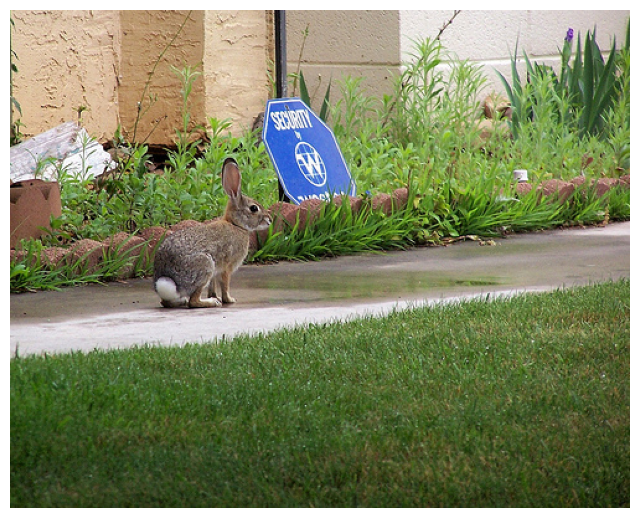

Projection score: 0.756074070930481


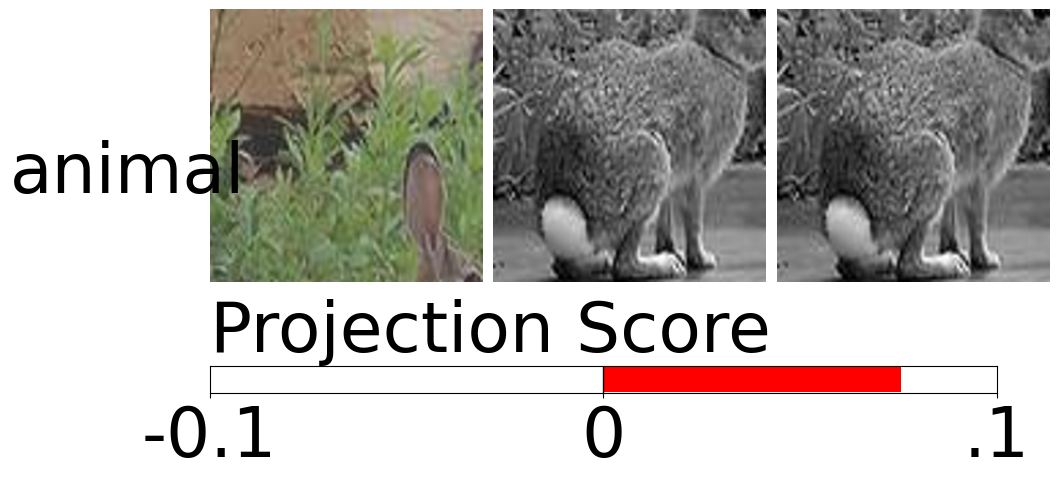

Projection score: 0.6064968705177307


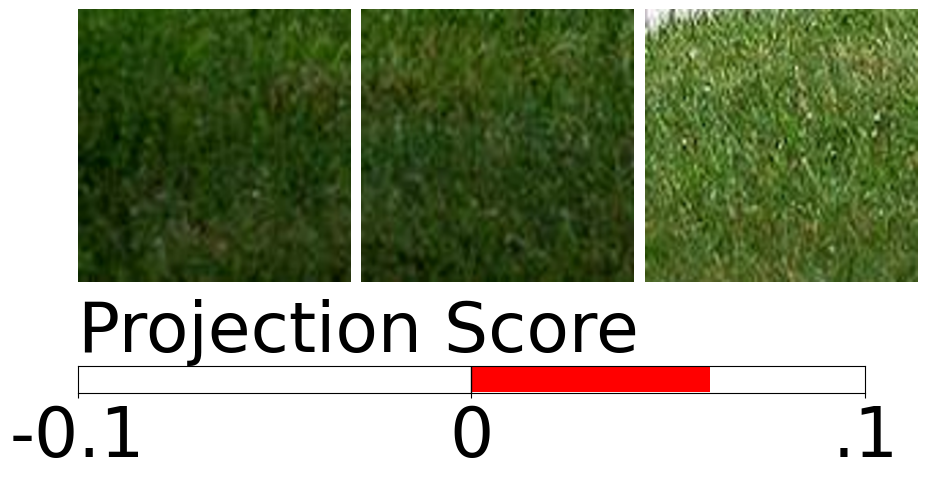

IndexError: list index out of range

In [29]:
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_image[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion(a_test_phrase_with_image, test_data_remapped)

## Explain text with images in vlm.
### We have the image concepts

### First get the embedding for a text 



In [ ]:
# Get the feature for one image 

!cd ../ && python src/save_features.py \
    --model_name "google/gemma-3n-E4B-it" \
    --dataset_name "text" \
    --data_dir "rabbit" \
    --hook_name  "save_hidden_states_noun_phrase" \
    --modules_to_hook "model.language_model.layers.20.input_layernorm" \
    --save_dir "/mnt/abka03/xl-vlms" \
    --save_filename "qwen2_text_hidden_states" \
    --generation_mode \
    --save_only_generated_tokens \
    --slice_prediction \
    --prompt_template "cgdl" \
    --exact_match_modules_to_hook \
    --cache_dir "/mnt/abka03/xl-vlms/cache"

In [ ]:
text_feature_path = "/mnt/abka03/xl-vlms/features/save_hidden_states_noun_phrase_qwen2_text_hidden_states.pth"
output = torch.load(text_feature_path)
#print(output)
absolute_features = output["hidden_states"]
print(output["model_predictions"])



In [ ]:
# Project the text in to the concept and explain
from analysis.feature_decomposition import get_feature_matrix
script_path = "/mnt/abka03/Projects/xl-vlms/src"
if script_path not in sys.path:
    sys.path.append(script_path)


module_name = 'model.language_model.norm'
token_idx = None
output = torch.load(text_feature_path)
absolute_features = output["hidden_states"]
feat_matrix = get_feature_matrix(
            absolute_features,
            module_name=module_name,
            token_idx=token_idx,
        )


analysis_model = concept_data["analysis_model"]
grounding_words = concept_data["text_grounding"]
feat_matrix = feat_matrix.float()
print(feat_matrix.type(), concept_data["concepts"].T.type())
projections = feat_matrix @ concept_data["concepts"].T
projections = projections / projections.max() *500
print(projections.shape)
top_powerful_indexes = find_top_n_powerful_projection(projections, n)
test_text = output['model_predictions']
def remap_prjection_text(top_powerful_indexes, test_text, image_concept_path,  text_concept_path):
    if len(top_powerful_indexes) != len(test_text):
        raise ValueError("The projection list and image list of test data not have equal number.")
    
    print("Test cocept text:",len(test_text))
    final_result = {}
    for each_image_path, concept_indexs in zip(test_text, top_powerful_indexes):
        final_result[each_image_path[0]] = {'vis_concepts':[(image_concept_path[i[0]], i[1]) for i in concept_indexs],  'text_concept': [( text_concept_path[i[0]],i[1]) for i in concept_indexs]}

    return final_result


text_grounding_paths = concept_data["text_grounding"]
test_data_remapped_text = remap_prjection_text(top_powerful_indexes, test_text , image_grounding_paths, text_grounding_paths)




def  visualize_grounding_text(concept_idx, concept_text, image_paths):
    concept_names_scores = concept_text[concept_idx]
    paths = image_paths[concept_idx][0]
    importance = image_paths[concept_idx][1]
    num_imgs = len(paths)
    images = []
    concept_list = []

    for path in paths:
        concept, path = path.split("@")
        concept_list.append(concept.lower())
        cur_img = load_image(path)
        cur_img = np.array(Image.fromarray(cur_img).resize([256, 256]))
        images.append(cur_img)

    unique_concepts = sorted(set(concept_list))
    projection_score = concept_names_scores[1].item()

    # Increase figure height to fit projection score bar
    fig = plt.figure(figsize=(num_imgs * 2.5 + 3, 5.5))  # Height increased

    # Title row: unique concepts
    #fig.suptitle(', '.join(unique_concepts), fontsize=35, x=0.5, y=0.95)

    # Image layout
    gap = 0.01
    image_width = (0.8 - (num_imgs - 1) * gap) / num_imgs

    for i in range(num_imgs):
        left = tex_grounding_loc + i * (image_width + gap)
        ax = fig.add_axes([left, 0.25, image_width, 0.6])  # Adjusted y-position
        ax.imshow(images[i])
        ax.axis('off')

    # Add concept ID and names on the left
    label_text = f""''.join(concept_names_scores[0])
    fig.text(0.01, 0.5, label_text, va='center', ha='left', fontsize=font_size)

    # Add projection score bar (horizontal, centered on 0)
    ax_bar = fig.add_axes([0.2, 0.1, 0.75, 0.05])  # [left, bottom, width, height]
    ax_bar.barh([0], [projection_score], height=0.5, color='red')
    ax_bar.set_xlim([-500, 500])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([-500, 0, 500])
    ax_bar.set_xticklabels(['-500', '0', '500'], fontsize=font_size)
    ax_bar.axvline(0, color='black', linewidth=1)  # center line
    ax_bar.set_title('Projection Score', fontsize=font_size, loc='left')

    # Add value to the right of the bar
    #fig.text(0.88, 0.11, f"{round(projection_score)}", va='center', ha='left', fontsize=40)
    plt.savefig(f"/mnt/abka03/Projects/xl-vlms/plots/mcox/local_explanation/grounding.svg", format='svg')

    plt.show()

n=40
def local_explantion_text(a_test_image,test_data_remapped):
    
    text_concepts = test_data_remapped[a_test_image]
    for i in range(n):
         visualize_grounding_text(i, text_concepts['text_concept'], text_concepts['vis_concepts'] )
test_text = output['model_predictions']
print("All text:", test_text)
#explain one noun phrase
phrase_number = 0
a_test_phrase_with_image = test_text[phrase_number][0]
print("Phrase at image:", a_test_phrase_with_image)
local_explantion_text(a_test_phrase_with_image, test_data_remapped_text )

